
# 10. Hypothesis Testing, Type I/II Errors, and Power

Hypothesis testing is often taught as a mechanical sequence: write down a null, compute a statistic, compare a p-value to 0.05, and declare success or failure. That ritual is easy to memorize and easy to misuse.

In decision science, hypothesis testing is more useful when it is framed as an error-control tool. A test does not prove a theory. It gives us a procedure that, under stated assumptions, limits how often we make certain kinds of mistakes. The practical question is not simply whether we rejected a null. The practical question is whether the design, the evidence, and the stakes together justify an action.

We develop that view using a realistic product-operations example: a new AI-assisted triage template for premium support tickets. The proposed workflow may reduce average resolution time, but rolling it out too early could waste training time and create false confidence. At the same time, failing to adopt a genuinely useful system also carries a cost. Hypothesis testing helps us structure that tradeoff.



## Learning Objectives

After working through this lecture, you should be able to:

1. State null and alternative hypotheses in a decision-relevant way.
2. Explain what a p-value does and does not tell us.
3. Distinguish Type I errors, Type II errors, and statistical power.
4. Use simulation to understand false positives and false negatives under repeated sampling.
5. Recognize why low-power studies produce unstable conclusions even when they achieve significance.
6. Connect test results to launch decisions through explicit decision rules.


In [1]:
# Load the libraries and notebook settings used in the examples below.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
pd.options.display.float_format = "{:.4f}".format

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display

## 1. Why Hypothesis Tests Exist

Suppose the outcome of interest is average ticket-resolution time, measured in minutes. Let

$$
\Delta = \mu_{\text{triage template}} - \mu_{\text{status quo}}.
$$

A negative value of $\Delta$ means the new workflow reduces resolution time, which is good for operations. The most common starting hypotheses are

$$
H_0: \Delta = 0
\qquad \text{versus} \qquad
H_1: \Delta \neq 0.
$$

These hypotheses are not the whole scientific story. They are a decision device. If we reject $H_0$, we are saying that the observed data would be unusual if there were truly no mean difference. If we fail to reject $H_0$, we are saying the data do not provide strong enough evidence against that benchmark.

The benchmark matters because two errors are possible:

- A **Type I error** rejects $H_0$ when no real improvement exists.
- A **Type II error** fails to reject $H_0$ when a real improvement does exist.

The significance level $\alpha$ controls the long-run frequency of Type I errors, and statistical power $1 - \beta$ measures the long-run chance of detecting a real effect of a given size.

In [2]:
# Define helper functions so repeated calculations stay readable.
def make_triage_experiment(
    n_per_group=180,
    baseline_mean=18.3,
    true_effect=-0.9,
    sigma=4.8,
    seed=606,
):
    """
    Construct the triage experiment object used in this lecture.
    
    Parameters:
        n_per_group: Sample size or group size used by the simulation, resampling, or inference step.
        baseline_mean: Control-group or baseline mean used to generate simulated outcomes.
        true_effect: True treatment effect imposed in the simulation.
        sigma: Outcome standard deviation used to control noise in simulated experiments.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A pandas DataFrame containing the simulated status-quo and AI-template pilot groups with their resolution-time outcomes.
    
    Idea:
        Construct a controlled pilot where treatment assignment and operational outcomes are explicit, allowing testing errors and power to be studied directly.
    """
    rng = np.random.default_rng(seed)
    control = np.clip(rng.normal(loc=baseline_mean, scale=sigma, size=n_per_group), 2, None)
    treatment = np.clip(rng.normal(loc=baseline_mean + true_effect, scale=sigma, size=n_per_group), 2, None)
    return pd.DataFrame(
        {
            "group": ["Status quo"] * n_per_group + ["AI triage template"] * n_per_group,
            "resolution_minutes": np.concatenate([control, treatment]),
        }
    )


def welch_test_summary(frame):
    """
    Compute the welch test summary quantity used in the statistical or decision-science workflow.
    
    Parameters:
        frame: Input DataFrame or data slice to summarize.
    
    Returns:
        A dictionary containing the treatment difference, standard error, t statistic, degrees of freedom, p-value, and confidence interval.
    
    Idea:
        Use Welch's test to compare means without assuming equal variances, which is often more realistic for operational pilots.
    """
    treatment = frame.loc[frame["group"] == "AI triage template", "resolution_minutes"].to_numpy()
    control = frame.loc[frame["group"] == "Status quo", "resolution_minutes"].to_numpy()

    diff = treatment.mean() - control.mean()
    t_stat, p_value = stats.ttest_ind(treatment, control, equal_var=False)
    se = np.sqrt(treatment.var(ddof=1) / len(treatment) + control.var(ddof=1) / len(control))
    df_num = (treatment.var(ddof=1) / len(treatment) + control.var(ddof=1) / len(control)) ** 2
    df_den = (treatment.var(ddof=1) / len(treatment)) ** 2 / (len(treatment) - 1)
    df_den += (control.var(ddof=1) / len(control)) ** 2 / (len(control) - 1)
    df = df_num / df_den
    crit = stats.t.ppf(0.975, df)
    ci_low = diff - crit * se
    ci_high = diff + crit * se

    return {
        "difference_in_means": diff,
        "standard_error": se,
        "t_statistic": t_stat,
        "degrees_of_freedom": df,
        "p_value": p_value,
        "ci_low": ci_low,
        "ci_high": ci_high,
    }


pilot = make_triage_experiment()
pilot_summary = (
    pilot.groupby("group")["resolution_minutes"]
    .agg(["count", "mean", "std", "median"])
    .rename(columns={"count": "n", "mean": "mean_minutes", "std": "sd_minutes", "median": "median_minutes"})
)

smart_display(pilot_summary)

,n,mean_minutes,sd_minutes,median_minutes
group,,,,
AI triage template,180,17.1036,4.6634,17.1644
Status quo,180,18.0766,4.3513,18.4442


### Dataset and Experiment Design

The dataset is a simulated randomized pilot for an AI-assisted triage template. We create two groups: tickets handled under the status quo workflow and tickets handled with the new template. The primary outcome is resolution time in minutes, and lower values are better. The treatment assignment is clean by design, which lets the notebook focus on hypothesis-testing logic while holding observational bias out of the main example.

The first experiment analyzes one realized pilot, which mirrors the kind of result a team might actually bring to a launch meeting. The later experiments repeat the same design thousands of times under known true effects. That repeated-sampling view is what turns Type I error, Type II error, and power from abstract terms into observable operating characteristics.

The design intentionally separates statistical evidence from launch readiness. A small p-value can show that the data are surprising under a no-effect benchmark, but the pilot also needs enough power and enough practical effect size to support a real deployment decision.


## 2. A Single Realized Test Is Only One Draw from a Repeated-Sampling Process

For the realized experiment, we compute a Welch two-sample t test. This test compares the observed mean difference to the amount of variation we would expect from random assignment and residual noise.

The p-value answers a specific question:

> If the true mean difference were zero, how unusual would a result this extreme or more extreme be?

That is a useful calibration question. It is **not** the same as asking for the probability that the null is true, and it is not the probability that our decision is correct.


In [3]:
# Build a summary table that supports the interpretation in the surrounding notes.
observed_test = welch_test_summary(pilot)

test_table = pd.DataFrame(
    {
        "quantity": [
            "Mean resolution time: status quo",
            "Mean resolution time: AI template",
            "Observed difference (AI - status quo)",
            "Standard error of difference",
            "Welch t statistic",
            "Two-sided p-value",
            "95% CI lower bound",
            "95% CI upper bound",
        ],
        "value": [
            pilot.loc[pilot["group"] == "Status quo", "resolution_minutes"].mean(),
            pilot.loc[pilot["group"] == "AI triage template", "resolution_minutes"].mean(),
            observed_test["difference_in_means"],
            observed_test["standard_error"],
            observed_test["t_statistic"],
            observed_test["p_value"],
            observed_test["ci_low"],
            observed_test["ci_high"],
        ],
    }
)

smart_display(test_table)

if observed_test["p_value"] < 0.05:
    smart_display(
        Markdown(
            f"The pilot produces a statistically significant result at the 5% level: "
            f"the estimated mean difference is **{observed_test['difference_in_means']:.2f} minutes**, "
            f"with a 95% interval of **[{observed_test['ci_low']:.2f}, {observed_test['ci_high']:.2f}]**."
        )
    )
else:
    smart_display(
        Markdown(
            f"The pilot does **not** reject the null at the 5% level: "
            f"the estimated mean difference is **{observed_test['difference_in_means']:.2f} minutes**, "
            f"with a 95% interval of **[{observed_test['ci_low']:.2f}, {observed_test['ci_high']:.2f}]**."
        )
    )


,quantity,value
0,Mean resolution time: status quo,18.0766
1,Mean resolution time: AI template,17.1036
2,Observed difference (AI - status quo),-0.9731
3,Standard error of difference,0.4754
4,Welch t statistic,-2.0468
5,Two-sided p-value,0.0414
6,95% CI lower bound,-1.9080
7,95% CI upper bound,-0.0381


The pilot produces a statistically significant result at the 5% level: the estimated mean difference is **-0.97 minutes**, with a 95% interval of **[-1.91, -0.04]**.


This realized pilot lands in a region that often tempts overconfidence. The p-value crosses the conventional 0.05 threshold, so a purely ritualized reading would say “the intervention works.” But that reading is incomplete.

The interval is narrow enough to rule out zero, yet it still includes very small improvements. In operational terms, this means the study suggests a benefit, but it does **not** yet prove that the benefit is large enough to matter for a full rollout. That distinction becomes even clearer once we examine repeated sampling and statistical power.

## 3. Type I Error: False Positives Under the Null

A significance level such as $\alpha = 0.05$ is a long-run error-rate promise. If there is truly no mean improvement and we repeat the same experiment many times, about 5% of those experiments should reject the null just by chance.

That is what a Type I error means. It is not the chance that *this* specific rejection is false. It is the long-run false positive rate of the testing procedure under repeated use.

,scenario,rejection_rate,mean_p_value
0,True null (no improvement),0.0484,0.4991
1,Weak real improvement (-0.5 min),0.1650,0.3749


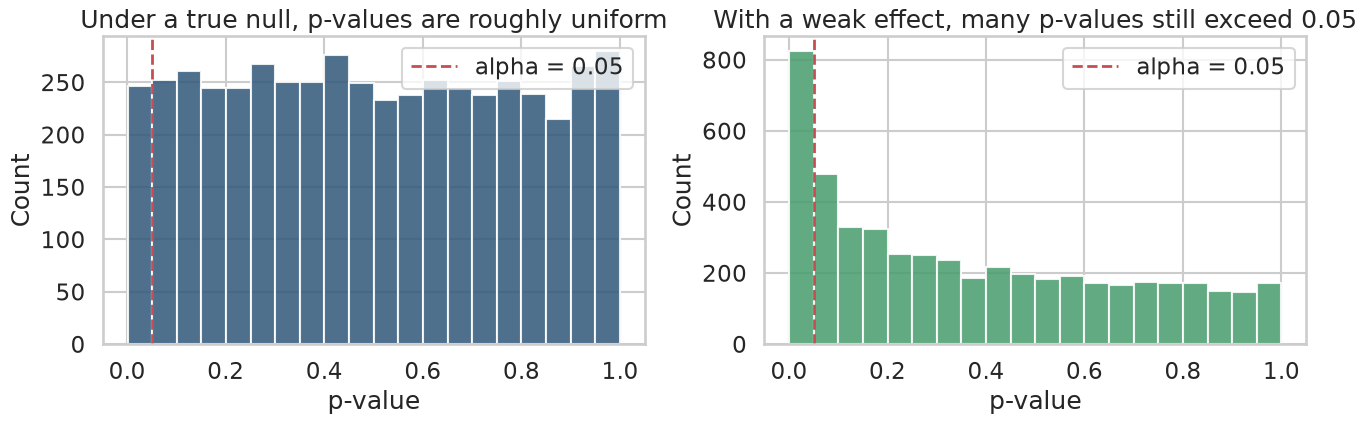

In [4]:
# Define helper functions so repeated calculations stay readable.
def simulate_experiments(
    n_per_group,
    true_effect,
    sigma=4.8,
    reps=4000,
    alpha=0.05,
    seed=123,
    baseline_mean=18.3,
):
    """
    Simulate experiments for intuition, calibration, or operating-characteristic checks.
    
    Parameters:
        n_per_group: Sample size or group size used by the simulation, resampling, or inference step.
        true_effect: True treatment effect imposed in the simulation.
        sigma: Outcome standard deviation used to control noise in simulated experiments.
        reps: Number of repeated samples, bootstrap draws, or simulation replications.
        alpha: Significance level, regularization strength, or model parameter as defined by the calling cell.
        seed: Random seed used to make the simulation or resampling reproducible.
        baseline_mean: Control-group or baseline mean used to generate simulated outcomes.
    
    Returns:
        A pandas DataFrame of repeated experiment results for power, Type I error, and estimate-stability analysis.
    
    Idea:
        Repeat the experimental design under known effects so Type I error, Type II error, and power become observable frequencies.
    """
    rng = np.random.default_rng(seed)
    records = []
    for _ in range(reps):
        control = rng.normal(baseline_mean, sigma, n_per_group)
        treatment = rng.normal(baseline_mean + true_effect, sigma, n_per_group)
        diff = treatment.mean() - control.mean()
        _, p_value = stats.ttest_ind(treatment, control, equal_var=False)
        records.append({"difference": diff, "p_value": p_value, "reject": p_value < alpha})
    return pd.DataFrame(records)


null_runs = simulate_experiments(n_per_group=180, true_effect=0.0, reps=5000, seed=41)
weak_effect_runs = simulate_experiments(n_per_group=180, true_effect=-0.5, reps=5000, seed=42)

error_summary = pd.DataFrame(
    [
        {
            "scenario": "True null (no improvement)",
            "rejection_rate": null_runs["reject"].mean(),
            "mean_p_value": null_runs["p_value"].mean(),
        },
        {
            "scenario": "Weak real improvement (-0.5 min)",
            "rejection_rate": weak_effect_runs["reject"].mean(),
            "mean_p_value": weak_effect_runs["p_value"].mean(),
        },
    ]
)

smart_display(error_summary)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

axes[0].hist(null_runs["p_value"], bins=20, color="#355C7D", alpha=0.88, edgecolor="white")
axes[0].axvline(0.05, color="#C44E52", linestyle="--", linewidth=2, label="alpha = 0.05")
axes[0].set_title("Under a true null, p-values are roughly uniform")
axes[0].set_xlabel("p-value")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(weak_effect_runs["p_value"], bins=20, color="#4C9F70", alpha=0.88, edgecolor="white")
axes[1].axvline(0.05, color="#C44E52", linestyle="--", linewidth=2, label="alpha = 0.05")
axes[1].set_title("With a weak effect, many p-values still exceed 0.05")
axes[1].set_xlabel("p-value")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

The null histogram is the key calibration picture. When the null is true, small p-values should occur only occasionally, which is exactly why the false positive rate tracks $\alpha$.

The second panel is equally important. Even when a real improvement exists, p-values need not pile up near zero unless the design is powerful enough. In this example, a modest true effect of half a minute produces many studies that still fail to reject. That is the beginning of Type II error.

## 4. Type II Error and Power Depend on Effect Size, Noise, and Sample Size

A Type II error occurs when a real improvement exists but the study fails to reject the null. The probability of that failure is denoted by $\beta$, and statistical power is

$$
\text{Power} = 1 - \beta.
$$

Power is not a universal number attached to a test. It depends on the design and on the size of the effect we care about detecting. Larger samples, lower noise, and larger true effects all increase power.

,n_per_group,true_effect,rejection_rate,interpretation
8,180,0.0000,0.0540,Type I error rate under null
9,180,-0.5000,0.1675,Power against this true effect
10,180,-1.0000,0.5108,Power against this true effect
11,180,-1.5000,0.8357,Power against this true effect


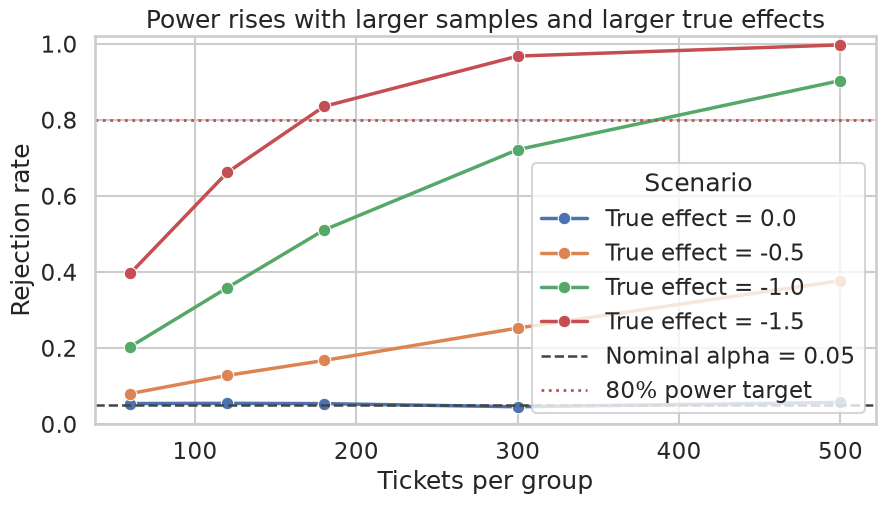

In [5]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
power_records = []
for n_per_group in [60, 120, 180, 300, 500]:
    for true_effect in [0.0, -0.5, -1.0, -1.5]:
        sim = simulate_experiments(
            n_per_group=n_per_group,
            true_effect=true_effect,
            reps=4000,
            seed=1000 + n_per_group * 10 + int(abs(true_effect) * 100),
        )
        power_records.append(
            {
                "n_per_group": n_per_group,
                "true_effect": true_effect,
                "rejection_rate": sim["reject"].mean(),
            }
        )

power_grid = pd.DataFrame(power_records)
current_design = power_grid.query("n_per_group == 180").copy()
current_design["interpretation"] = np.where(
    current_design["true_effect"] == 0,
    "Type I error rate under null",
    "Power against this true effect",
)

smart_display(current_design)

plot_grid = power_grid.copy()
plot_grid["effect_label"] = plot_grid["true_effect"].map(
    {
        0.0: "True effect = 0.0",
        -0.5: "True effect = -0.5",
        -1.0: "True effect = -1.0",
        -1.5: "True effect = -1.5",
    }
)

plt.figure(figsize=(9.2, 5.4))
sns.lineplot(
    data=plot_grid,
    x="n_per_group",
    y="rejection_rate",
    hue="effect_label",
    marker="o",
    linewidth=2.5,
)
plt.axhline(0.05, color="#444444", linestyle="--", linewidth=1.8, label="Nominal alpha = 0.05")
plt.axhline(0.80, color="#C44E52", linestyle=":", linewidth=2.0, label="80% power target")
plt.title("Power rises with larger samples and larger true effects")
plt.xlabel("Tickets per group")
plt.ylabel("Rejection rate")
plt.ylim(0, 1.02)
plt.legend(title="Scenario", loc="lower right")
plt.tight_layout()
plt.show()



For the current pilot size of 180 tickets per group, the design controls Type I error reasonably well, but it has only moderate power against a one-minute improvement. That means a meaningful operational effect could easily be missed in repeated use of this design.

This matters because “non-significant” is often misread as “nothing is happening.” In reality, it can simply mean the experiment was too small or too noisy to speak decisively. Hypothesis testing without power analysis encourages that mistake.


## 5. Low-Power Studies Make Significant Results Unstable

There is another subtle failure mode. In low-power settings, the experiments that *do* reach significance are often the lucky ones with unusually large estimated effects. As a result, significant findings from weak designs can exaggerate the magnitude of the underlying effect.

This is one reason to treat “p < 0.05” as evidence for a launch discussion, with the estimated size still needing scrutiny.


,n_per_group,power,mean_estimate_all_runs,mean_estimate_significant_runs,exaggeration_ratio,type_s_rate_within_significant_runs
0,60,0.0880,-0.5041,-1.8334,3.6669,0.0614
1,120,0.1220,-0.4998,-1.4463,2.8926,0.0279
2,180,0.1758,-0.5102,-1.2253,2.4506,0.0102
3,300,0.2440,-0.5006,-1.0015,2.0030,0.0033
4,500,0.3720,-0.4965,-0.8082,1.6163,0.0005


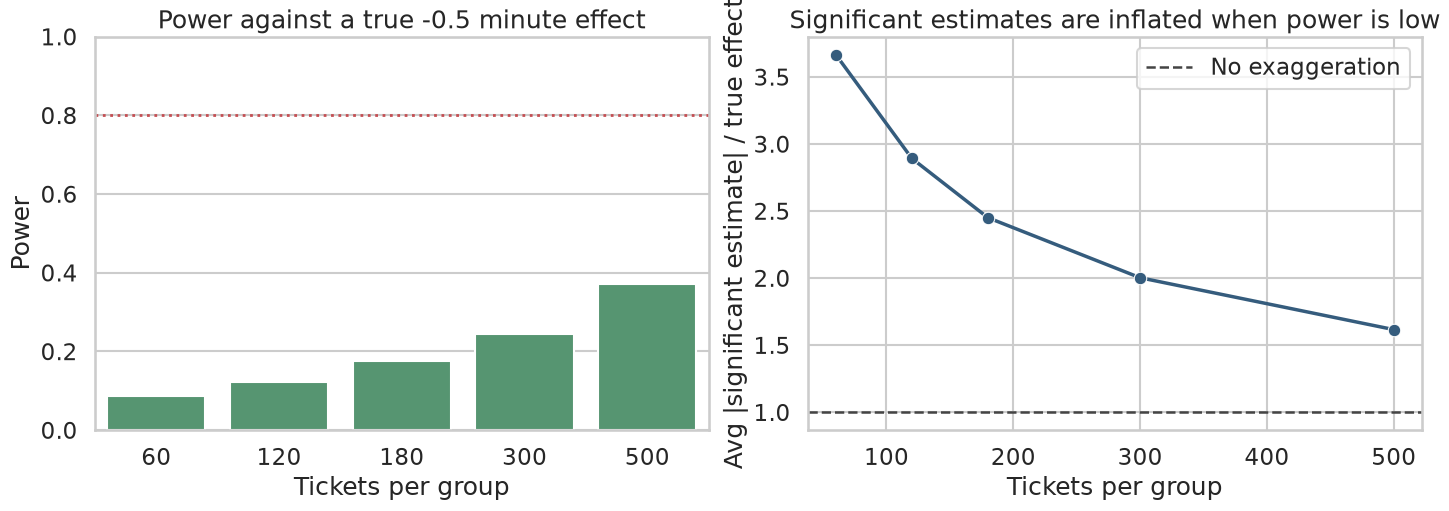

In [6]:
# Define helper functions so repeated calculations stay readable.
def summarize_significant_results(n_per_group, true_effect=-0.5, sigma=4.8, reps=5000, seed=555):
    """
    Summarize significant results into a compact table or record.
    
    Parameters:
        n_per_group: Sample size or group size used by the simulation, resampling, or inference step.
        true_effect: True treatment effect imposed in the simulation.
        sigma: Outcome standard deviation used to control noise in simulated experiments.
        reps: Number of repeated samples, bootstrap draws, or simulation replications.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A dictionary containing the summarize significant results quantities used for interpretation and reporting.
    
    Idea:
        Summarize only the significant results to expose selection effects: the results that get reported are not a random subset of all results.
    """
    runs = simulate_experiments(
        n_per_group=n_per_group,
        true_effect=true_effect,
        sigma=sigma,
        reps=reps,
        seed=seed + n_per_group,
    )
    significant = runs.loc[runs["reject"]].copy()
    return {
        "n_per_group": n_per_group,
        "power": runs["reject"].mean(),
        "mean_estimate_all_runs": runs["difference"].mean(),
        "mean_estimate_significant_runs": significant["difference"].mean() if len(significant) else np.nan,
        "exaggeration_ratio": abs(significant["difference"].mean()) / abs(true_effect) if len(significant) else np.nan,
        "type_s_rate_within_significant_runs": (significant["difference"] > 0).mean() if len(significant) else np.nan,
    }


instability = pd.DataFrame(
    [summarize_significant_results(n) for n in [60, 120, 180, 300, 500]]
)

smart_display(instability)

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.0), constrained_layout=True)

sns.barplot(data=instability, x="n_per_group", y="power", color="#4C9F70", ax=axes[0])
axes[0].axhline(0.80, color="#C44E52", linestyle=":", linewidth=2)
axes[0].set_title("Power against a true -0.5 minute effect")
axes[0].set_xlabel("Tickets per group")
axes[0].set_ylabel("Power")
axes[0].set_ylim(0, 1)

sns.lineplot(data=instability, x="n_per_group", y="exaggeration_ratio", marker="o", linewidth=2.5, color="#355C7D", ax=axes[1])
axes[1].axhline(1.0, color="#444444", linestyle="--", linewidth=1.8, label="No exaggeration")
axes[1].set_title("Significant estimates are inflated when power is low")
axes[1].set_xlabel("Tickets per group")
axes[1].set_ylabel("Avg |significant estimate| / true effect")
axes[1].legend()

plt.show()


This figure is one of the most important in the notebook. When power is weak, most studies fail to detect the real effect. The smaller subset that *does* achieve significance tends to overstate the magnitude of the benefit.

That means a low-power program can generate two opposite managerial errors at once:

- many real improvements are missed entirely, and
- the few detected improvements often look larger than they really are.

This is a strong argument for treating significance thresholds as only one part of a broader decision workflow.


## 6. Misinterpretations to Avoid

| Common statement | Why it is wrong | Better interpretation |
| --- | --- | --- |
| “A p-value of 0.04 means there is a 4% chance the null is true.” | A p-value is computed **assuming** the null is true; it is not a posterior probability for the null. | A p-value of 0.04 means data this extreme would be uncommon if the no-effect benchmark were correct. |
| “Failing to reject the null proves there is no effect.” | A study can miss real effects because of noise or low power. | Non-rejection means the study did not provide enough evidence against the null. |
| “Alpha = 0.05 means 5% of significant results are false.” | Alpha is a long-run false positive rate under repeated testing when the null is true. | Alpha controls one procedural error rate, not the truth status of a single result. |
| “If a result is significant, the estimated effect is trustworthy.” | Underpowered studies often yield unstable or exaggerated significant estimates. | Significance belongs alongside confidence intervals, power, and practical thresholds. |



## 7. Decision Guardrails for the Triage-Template Pilot

Suppose the operations team sets a minimum practically important improvement at **1 minute faster per ticket**. That is, a smaller gain may not justify training, maintenance, and workflow complexity.

Now the question is whether the full evidence package supports an action.


In [7]:
# Build a summary table that supports the interpretation in the surrounding notes.
current_power_table = power_grid.query("n_per_group == 180").copy()
current_power_table = current_power_table.set_index("true_effect")["rejection_rate"].to_dict()

mde = -1.0
observed_diff = observed_test["difference_in_means"]
ci_low = observed_test["ci_low"]
ci_high = observed_test["ci_high"]

launch_table = pd.DataFrame(
    [
        {
            "criterion": "Statistical significance at 5%",
            "observed_value": observed_test["p_value"],
            "decision_rule": "p-value < 0.05",
            "passes": observed_test["p_value"] < 0.05,
        },
        {
            "criterion": "Direction of effect",
            "observed_value": observed_diff,
            "decision_rule": "Estimated difference < 0 (faster is better)",
            "passes": observed_diff < 0,
        },
        {
            "criterion": "Rules out no effect",
            "observed_value": ci_high,
            "decision_rule": "Upper 95% CI bound < 0",
            "passes": ci_high < 0,
        },
        {
            "criterion": "Rules out too-small benefit",
            "observed_value": ci_high,
            "decision_rule": "Upper 95% CI bound <= -1.0 min",
            "passes": ci_high <= mde,
        },
        {
            "criterion": "Design power for a 1-minute gain",
            "observed_value": current_power_table[-1.0],
            "decision_rule": "Power >= 0.80",
            "passes": current_power_table[-1.0] >= 0.80,
        },
    ]
)

smart_display(launch_table)

if launch_table["passes"].all():
    recommendation = (
        "The pilot clears all statistical and operational guardrails. A broader rollout is defensible."
    )
else:
    recommendation = (
        "The pilot provides evidence that the triage template likely helps, but it does not yet clear the "
        "stronger operational guardrails. In particular, the interval still allows benefits smaller than the "
        "1-minute threshold, and the design had only moderate power for detecting that threshold effect. "
        "A prudent next step is a larger follow-up experiment or staged rollout before a full automatic launch."
    )

smart_display(Markdown(recommendation))


,criterion,observed_value,decision_rule,passes
0,Statistical significance at 5%,0.0414,p-value < 0.05,True
1,Direction of effect,-0.9731,Estimated difference < 0 (faster is better),True
2,Rules out no effect,-0.0381,Upper 95% CI bound < 0,True
3,Rules out too-small benefit,-0.0381,Upper 95% CI bound <= -1.0 min,False
4,Design power for a 1-minute gain,0.5108,Power >= 0.80,False


The pilot provides evidence that the triage template likely helps, but it does not yet clear the stronger operational guardrails. In particular, the interval still allows benefits smaller than the 1-minute threshold, and the design had only moderate power for detecting that threshold effect. A prudent next step is a larger follow-up experiment or staged rollout before a full automatic launch.

This connects the testing setup to decision risk. Thresholds, sample size, and the minimum effect worth acting on determine whether the workflow is more likely to create false alarms or miss useful changes.



## Wrap-Up

Hypothesis testing is most useful when we stop treating it as a binary truth machine. The core ideas are simple but powerful:

- Type I error reminds us that some discoveries are false alarms.
- Type II error reminds us that some real effects are missed.
- Power tells us how capable the design is at detecting effects we care about.
- Significant results from weak designs can still be unstable or exaggerated.

For decision-makers, the real goal is not to accumulate small p-values. The real goal is to build evidence strong enough, precise enough, and decision-relevant enough to justify action under uncertainty.



## References

- Neyman, J., & Pearson, E. S. (1933). *On the problem of the most efficient tests of statistical hypotheses*. *Philosophical Transactions of the Royal Society of London. Series A, Containing Papers of a Mathematical or Physical Character, 231*(694-706), 289-337. [https://doi.org/10.1098/rsta.1933.0009](https://doi.org/10.1098/rsta.1933.0009)
- Wasserstein, R. L., & Lazar, N. A. (2016). *The ASA statement on p-values: Context, process, and purpose*. The American Statistician, 70(2), 129-133. [https://doi.org/10.1080/00031305.2016.1154108](https://doi.org/10.1080/00031305.2016.1154108)
- Cohen, J. (1994). *The earth is round (p < .05).* American Psychologist, 49(12), 997-1003. [https://doi.org/10.1037/0003-066X.49.12.997](https://doi.org/10.1037/0003-066X.49.12.997)
- Gelman, A., & Carlin, J. (2014). *Beyond power calculations*. Perspectives on Psychological Science, 9(6), 641-651. [https://doi.org/10.1177/1745691614551642](https://doi.org/10.1177/1745691614551642)
